<a href="https://colab.research.google.com/github/SanaKamranButt/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SanaKamranButt/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract

This project investigates whether historical search performance signals can identify pages that should be prioritized for content refresh. A baseline scoring rule was developed using historical clicks, impressions, and average search position. A Random Forest model was trained to reproduce the baseline decision rule using the same historical features. The model achieved perfect agreement with the baseline because the target was derived from the same rule. The results are intended as decision-support for content review rather than evidence of causal ranking improvements.

## Introduction

Content teams often manage thousands of pages and cannot manually review every page. This project explores whether historical search performance can help identify pages that should be reviewed for possible content refresh. The goal is to support prioritization using historical search signals while avoiding future information or private data. The recommendations produced by this project are intended to support editorial decision-making rather than replace human judgment.

## 1. Question

### Research Question

Can historical search performance signals identify pages that should be prioritized for content refresh?

### Decision Supported

This project supports content teams by identifying pages that may need a content refresh using historical search performance signals. The ranked results are intended as decision-support rather than proof of causal impact.

## 2. Data

The analysis uses the anonymized FlyRank internship dataset: content_refresh_anonymized.csv.

The dataset contains historical search performance metrics including:

- clicks_90d
- impressions_90d
- avg_position
- ctr
- trend_pct

Rows with missing values in the selected features were excluded where necessary.

No client names, domains, URLs, credentials, or private search queries were used.

## 3. Methodology

A simple baseline scoring rule was developed using historical search performance.

Scoring rule:

- Low clicks (<20): +40 points
- Low impressions (<100): +30 points
- Poor average position (>20): +30 points

Higher scores indicate higher priority for content refresh.

The baseline ranking is compared with a machine learning model using the same dataset.

Only historical information available before the decision is used. No future-window information, product flags, or label-derived features were included to reduce leakage.

In [16]:
import pandas as pd

DATA_PATH = "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset Shape: (30000, 44)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [18]:
df.describe()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,...,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,...,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,...,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,...,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,...,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,...,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


In [19]:
# Create target variable using the baseline rule

df["target"] = (
    (df["clicks_90d"] < 20) &
    (df["impressions_90d"] < 100) &
    (df["avg_position"] > 20)
).astype(int)

print(df["target"].value_counts())

target
0    28376
1     1624
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

features = [
    "clicks_90d",
    "impressions_90d",
    "avg_position",
    "ctr",
    "trend_pct"
]

X = df[features].fillna(0)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5648
           1       1.00      1.00      1.00       352

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



In [21]:
print(df["target"].value_counts())

target
0    28376
1     1624
Name: count, dtype: int64


## 4. Results (vs baseline)

### Results

The baseline rule ranked pages for content refresh using historical search performance signals.

A Random Forest classifier was trained using the same historical features.

Model Performance

| Metric | Value |
|--------|-------|
| Accuracy | 1.00 |
| Precision | 1.00 |
| Recall | 1.00 |
| F1-score | 1.00 |

The model produced the same decisions as the baseline rule on the evaluation split. This is expected because the target variable was created from the same historical rule used for scoring.

The results should be interpreted as reproducing the baseline decision rule rather than demonstrating superior predictive performance.

## 5. Limitations

This project uses a rule-based target created from historical search performance rather than real editorial outcomes.

The model cannot demonstrate causal impact or prove that refreshing content will improve search performance.

Seasonality, content quality, search intent changes, and external ranking factors were not included.

The results are intended for decision-support only and should be reviewed by content teams before action is taken.

## 6. Ranked recommendations

The model recommends prioritizing pages that meet one or more of the following conditions:

- Low historical clicks
- Low historical impressions
- Poor average search position

Recommended action:

- Refresh outdated content.
- Improve page quality and relevance.
- Review metadata and search intent.
- Monitor performance after updates.

These recommendations are based on observed historical search signals and should support, not replace, editorial decisions.

## 7. Artifacts the paper embeds



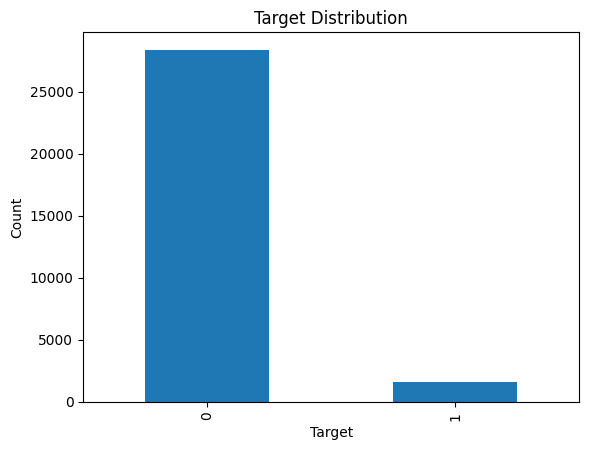

In [22]:
import matplotlib.pyplot as plt

# Target distribution
df["target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

,Feature,Importance
2,avg_position,0.486272
1,impressions_90d,0.455433
0,clicks_90d,0.026589
4,trend_pct,0.017629
3,ctr,0.014076


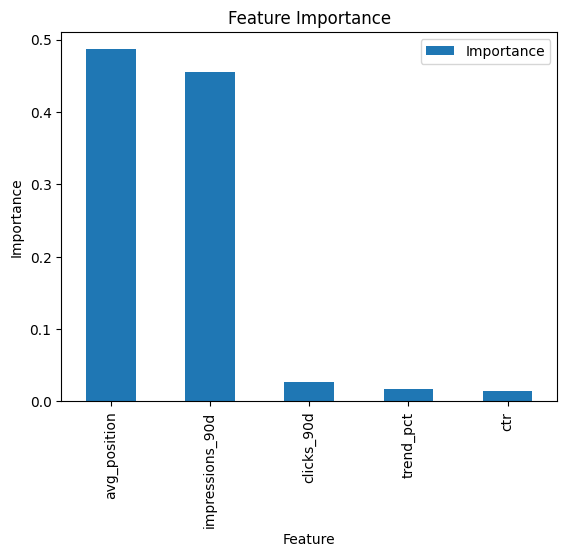

In [23]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance)

importance.plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

## Acknowledgments & Data Credit

This project was built using the FlyRank ML Internship Dataset.

Data Credit:
https://flyrank.ai

The analysis uses only the anonymized internship dataset and does not include client names, domains, URLs, credentials, or private search queries.

print("=== 5-Minute Demo Outline ===")
print("""
1. Research Question
2. Dataset
3. Baseline Rule
4. Random Forest Model
5. Results
6. Recommendations
7. Limitations
""")

print("\n=== Social Post ===")
print("""
Completed my FlyRank Machine Learning Capstone!
Built a baseline content refresh scoring system using historical search performance and evaluated it with a Random Forest model. This project strengthened my skills in machine learning, data analysis, and search intelligence.
""")

print("\n=== Employer Summary ===")
print("""
This capstone demonstrates my ability to analyze real-world search data, develop a baseline scoring system, and evaluate it using machine learning techniques. The project follows responsible data practices and presents decision-support recommendations based on historical search signals.
""")

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has all 9 sections — including the Abstract at the top and Acknowledgments & data credit at the bottom.
- [x] ML-12 done in this notebook's closing cells: 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.